# Задача 9. Тест на марковость 0-го vs 1-го порядка

**Цель:** статистически проверить, есть ли зависимость между соседними нуклеотидами.

**Модель 0-го порядка**
Каждый нуклеотид выбирается независимо с некоторыми вероятностями P(A), P(C), P(G), P(T). Вероятность динуклеотида P(XY) = P(X) × P(Y).


**Модель 1-го порядка**
Последовательность — Марковская цепь: вероятность нуклеотида зависит от предыдущего. 

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

In [3]:
nucleotides = ['A', 'C', 'G', 'T']

In [4]:
record = SeqIO.read('chr1.fa', 'fasta')
sequence = str(record.seq[3_000_000 : 3_100_000]).upper()

In [6]:
counts_nuc = np.array([sequence.count(n) for n in nucleotides], dtype=float)
P = counts_nuc / counts_nuc.sum()

print(f"\nЧастоты нуклеотидов в реальной последовательности:")
for n, p in zip(nucleotides, P):
    print(f"  {n}: {p:.4f}")


Частоты нуклеотидов в реальной последовательности:
  A: 0.2181
  C: 0.2807
  G: 0.2853
  T: 0.2159


In [7]:
# Генерируем случайную последовательность
np.random.seed(42)
random_seq = ''.join(np.random.choice(nucleotides, size=len(sequence), p=P))

In [11]:
def count_dinucleotides(seq, nucleotides): #матрица наблюдаемых динуклеотидов O_ij 
    idx = {n: i for i, n in enumerate(nucleotides)}
    O = np.zeros((4, 4), dtype=float)
    for k in range(len(seq) - 1): #идем по последовательности - для каждой пары к счетчику добавляем +1, к паре динуклеотидов которая встретилась
        i = idx[seq[k]]
        j = idx[seq[k + 1]]
        O[i, j] += 1
    return O

O_real = count_dinucleotides(sequence, nucleotides)
O_random = count_dinucleotides(random_seq, nucleotides)

In [16]:
def expected_dinucleotides(seq, nucleotides): #матрица ожидаемых частот E_ij = N * P(i) * P(j)
    n_pairs = len(seq) - 1
    counts = np.array([seq.count(nuc) for nuc in nucleotides], dtype=float)
    P_local = counts / counts.sum()
    E = n_pairs * np.outer(P_local, P_local)
    return E, P_local

E_real, P_real = expected_dinucleotides(sequence, nucleotides)
E_random, P_random = expected_dinucleotides(random_seq,     nucleotides)

In [17]:
def chi2_test(O, E, df=9): #хи-квадрат и p-value - у нас степень свободы = 9
    mask = E > 0
    chi2_stat = np.sum((O[mask] - E[mask])**2 / E[mask])
    p_value = stats.chi2.sf(chi2_stat, df=df)
    return chi2_stat, p_value

chi2_real, pval_real = chi2_test(O_real,   E_real)
chi2_random, pval_random = chi2_test(O_random, E_random)

In [21]:
print("Реальная последовательность - участок хромосомы человека")

print("\nМатрица наблюдаемых частот O_ij:")
print(f"{'':5}", end='')
for n in nucleotides:
    print(f"{n:>8}", end='')
print()
for i, n in enumerate(nucleotides):
    print(f"{n:5}", end='')
    for j in range(4):
        print(f"{int(O_real[i,j]):>8}", end='')
    print()

print("\nМатрица ожидаемых частот E_ij:")
print(f"{'':5}", end='')
for n in nucleotides:
    print(f"{n:>8}", end='')
print()
for i, n in enumerate(nucleotides):
    print(f"{n:5}", end='')
    for j in range(4):
        print(f"{E_real[i,j]:>8.1f}", end='')
    print()

print("\nСлучайная последовательность с заданными частотами")

print("\nМатрица наблюдаемых частот O_ij:")
print(f"{'':5}", end='')
for n in nucleotides:
    print(f"{n:>8}", end='')
print()
for i, n in enumerate(nucleotides):
    print(f"{n:5}", end='')
    for j in range(4):
        print(f"{int(O_random[i,j]):>8}", end='')
    print()

print("\nМатрица ожидаемых частот E_ij:")
print(f"{'':5}", end='')
for n in nucleotides:
    print(f"{n:>8}", end='')
print()
for i, n in enumerate(nucleotides):
    print(f"{n:5}", end='')
    for j in range(4):
        print(f"{E_random[i,j]:>8.1f}", end='')
    print()

Реальная последовательность - участок хромосомы человека

Матрица наблюдаемых частот O_ij:
            A       C       G       T
A        5265    4842    7645    4062
C        7764    9694    2902    7713
G        6191    7408   10015    4912
T        2594    6129    7964    4899

Матрица ожидаемых частот E_ij:
            A       C       G       T
A      4758.5  6123.8  6222.8  4708.7
C      6123.8  7880.9  8008.3  6059.8
G      6222.8  8008.3  8137.8  6157.8
T      4708.7  6059.8  6157.8  4659.5

Случайная последовательность с заданными частотами

Матрица наблюдаемых частот O_ij:
            A       C       G       T
A        4738    6132    6254    4737
C        6058    7875    8014    6014
G        6288    7928    8349    6115
T        4777    6026    6063    4631

Матрица ожидаемых частот E_ij:
            A       C       G       T
A      4779.0  6112.7  6269.7  4699.4
C      6112.7  7818.7  8019.4  6010.9
G      6269.7  8019.4  8225.3  6165.3
T      4699.4  6010.9  6165.3  4621.2

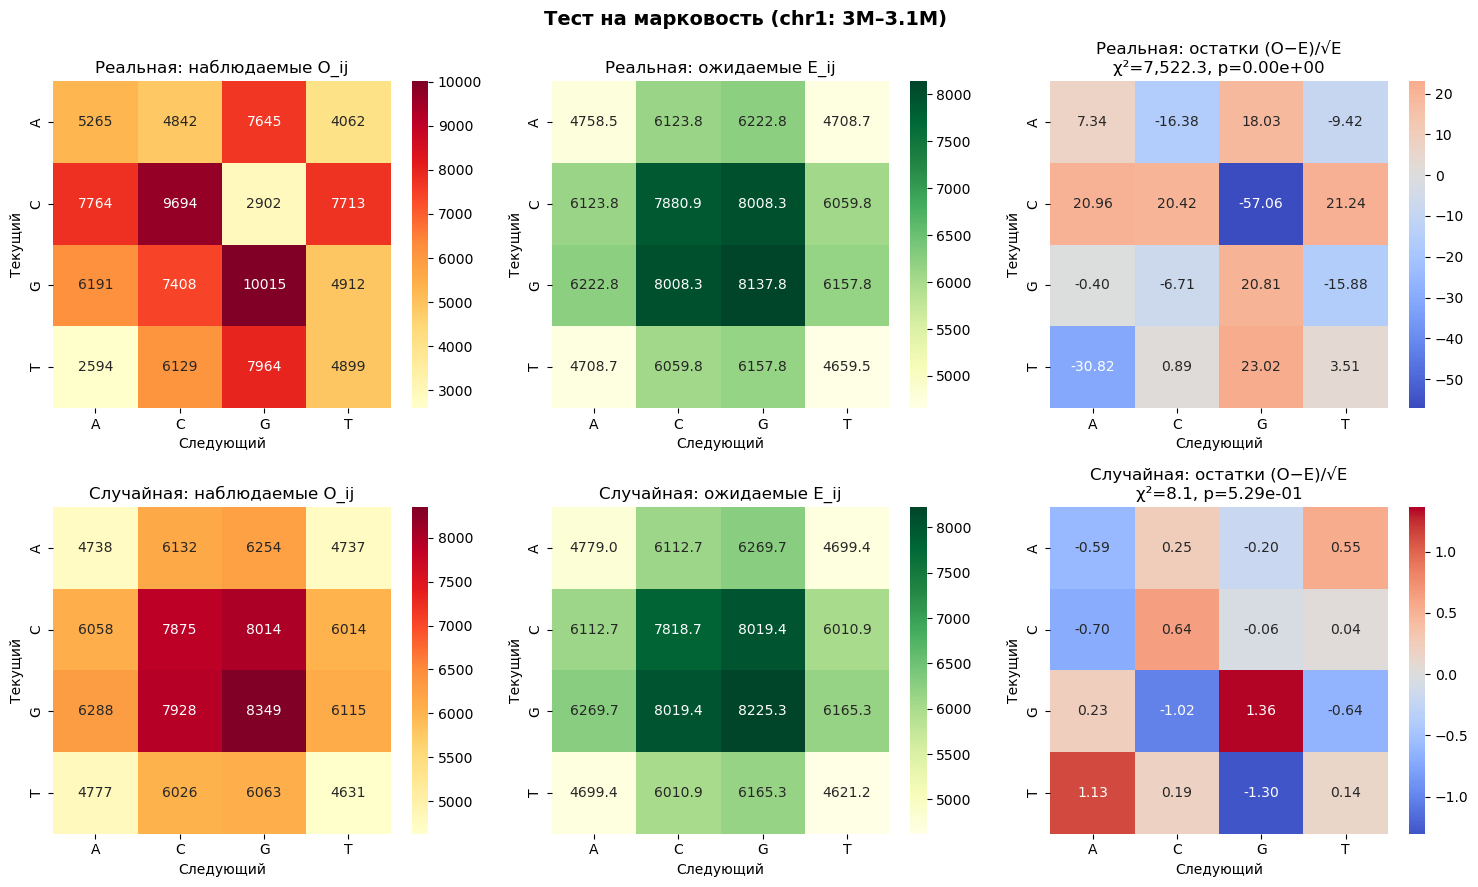

In [23]:
#выведем в виде heatmap для удобной визуализации
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Тест на марковость (chr1: 3M–3.1M)', fontsize=14, fontweight='bold')

for row, (O, E, title, chi2, pval) in enumerate([
    (O_real,   E_real,   'Реальная',  chi2_real,   pval_real),
    (O_random, E_random, 'Случайная', chi2_random, pval_random),
]):
    sns.heatmap(O, annot=True, fmt='.0f', xticklabels=nucleotides, yticklabels=nucleotides,
                ax=axes[row, 0], cmap='YlOrRd')
    axes[row, 0].set_title(f'{title}: наблюдаемые O_ij')
    axes[row, 0].set_xlabel('Следующий'); axes[row, 0].set_ylabel('Текущий')

    sns.heatmap(E, annot=True, fmt='.1f', xticklabels=nucleotides, yticklabels=nucleotides,
                ax=axes[row, 1], cmap='YlGn')
    axes[row, 1].set_title(f'{title}: ожидаемые E_ij')
    axes[row, 1].set_xlabel('Следующий'); axes[row, 1].set_ylabel('Текущий')

    residuals = (O - E) / np.sqrt(E + 1e-10)
    sns.heatmap(residuals, annot=True, fmt='.2f', xticklabels=nucleotides, yticklabels=nucleotides,
                ax=axes[row, 2], cmap='coolwarm', center=0)
    axes[row, 2].set_title(f'{title}: остатки (O−E)/√E\nχ²={chi2:,.1f}, p={pval:.2e}')
    axes[row, 2].set_xlabel('Следующий'); axes[row, 2].set_ylabel('Текущий')

plt.tight_layout()
plt.savefig('markov_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print(f"\nРеальная последовательность chr1:") #выводим резултаты проверки теории
print(f"  χ²      = {chi2_real:,.2f}")
print(f"  p-value = {pval_real:.2e}")
if pval_real < 0.05:
    print(f"  Вывод:  Работает модель 1 порядка - нуклеотиды зависимы")
else:
    print(f"  Вывод:  Работает модель 0 порядка")

print(f"\nСлучайная последовательность (те же частоты):")
print(f"  χ²      = {chi2_random:,.2f}")
print(f"  p-value = {pval_random:.2e}")
if pval_random < 0.05:
    print(f"  Вывод:  Модель 0 порядка не работает")
else:
    print(f"  Вывод:  Модель 0 порядка работает - распределение нуклеотидов независимо")


Реальная последовательность chr1:
  χ²      = 7,522.34
  p-value = 0.00e+00
  Вывод:  Работает модель 1 порядка - нуклеотиды зависимы

Случайная последовательность (те же частоты):
  χ²      = 8.05
  p-value = 5.29e-01
  Вывод:  Модель 0 порядка работает - распределение нуклеотидов независимо


Для **реальной последовательности** $\chi^2$ примерно равен 7522 , p-value равно 0. Следовательно, модель 0 порядка не работает - нуклеотиды зависят
друг от друга. Это видно, например, по динуклеотиду CG: он встречается значительно реже ожидаемого - это эффект CpG islands - исследовали в 7 задаче.

Для **случайной последовательности** $\chi^2$ = 8.05, p-value примерно равно 0.5. p-value > 0.05, следовательно применима модель 0 порядка  - нуклеотиды независимы, что логично, так как мы сами генерировали их случайно.

**Вывод:** реальный геном устроен не случайно — модель 0-го порядка его не описывает. Нужна марковская модель 1-го порядка, учитывающая зависимость каждого нуклеотида от предыдущего.